In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv(r'C:\Users\MKcomputer\Documents\LA_Crime_Analysis\Crime_Data_from_2020_to_Present.csv')

In [3]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,...,AO,Adult Other,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,330,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,700 S HILL ST,NaN,34.0459,-118.2545
2,200110444,04/14/2020 12:00:00 AM,02/13/2020 12:00:00 AM,1200,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,...,AA,Adult Arrest,845.0,NaN,NaN,NaN,200 E 6TH ST,NaN,34.0448,-118.2474
3,191501505,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,1730,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,998.0,NaN,NaN,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,415,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,Invest Cont,740.0,NaN,NaN,NaN,14400 TITUS ST,NaN,34.2198,-118.4468


In [4]:
df.shape

(752911, 28)

In [6]:
df.isnull().sum()

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           103261
Vict Age               0
Vict Sex           98230
Vict Descent       98236
Premis Cd              9
Premis Desc          435
Weapon Used Cd    491439
Weapon Desc       491439
Status                 0
Status Desc            0
Crm Cd 1              10
Crm Cd 2          697204
Crm Cd 3          751044
Crm Cd 4          752855
LOCATION               0
Cross Street      631859
LAT                    0
LON                    0
dtype: int64

In [8]:
f'Duplicates no: {df.duplicated().sum()}'

'Duplicates no: 0'

In [10]:
df.drop(columns=['Mocodes', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 
                  'Cross Street', 'Weapon Used Cd', 'Crm Cd 1',
                  'Rpt Dist No', 'Part 1-2', 'Crm Cd'], inplace=True)

In [12]:
df['Vict Sex'].fillna('Unkonwn', inplace= True)
df['Vict Descent'].fillna('Unkonwn', inplace= True)
df['Weapon Desc'].fillna('No Weapon', inplace= True)
df['Premis Desc'].fillna('Unkonwn', inplace= True)

C:\Users\MKcomputer\AppData\Local\Temp\ipykernel_19548\341285208.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Premis Desc'].fillna('Unkonwn', inplace= True)


In [13]:
df.isnull().sum()

DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA            0
AREA NAME       0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Premis Cd       9
Premis Desc     0
Weapon Desc     0
Status          0
Status Desc     0
LOCATION        0
LAT             0
LON             0
dtype: int64

In [14]:
df.shape[1]

18

In [15]:
df.dropna(subset=['Premis Cd'], inplace= True)

In [16]:
df.shape[0]

752902

In [17]:
df.isnull().sum()

DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA            0
AREA NAME       0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Premis Cd       0
Premis Desc     0
Weapon Desc     0
Status          0
Status Desc     0
LOCATION        0
LAT             0
LON             0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752902 entries, 0 to 752910
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   DR_NO         752902 non-null  int64  
 1   Date Rptd     752902 non-null  object 
 2   DATE OCC      752902 non-null  object 
 3   TIME OCC      752902 non-null  int64  
 4   AREA          752902 non-null  int64  
 5   AREA NAME     752902 non-null  object 
 6   Crm Cd Desc   752902 non-null  object 
 7   Vict Age      752902 non-null  int64  
 8   Vict Sex      752902 non-null  object 
 9   Vict Descent  752902 non-null  object 
 10  Premis Cd     752902 non-null  float64
 11  Premis Desc   752902 non-null  object 
 12  Weapon Desc   752902 non-null  object 
 13  Status        752902 non-null  object 
 14  Status Desc   752902 non-null  object 
 15  LOCATION      752902 non-null  object 
 16  LAT           752902 non-null  float64
 17  LON           752902 non-null  float64
dtypes: float6

In [19]:
df['DATE OCC']= pd.to_datetime(df['DATE OCC'])
df['Date Rptd']= pd.to_datetime(df['Date Rptd'])

C:\Users\MKcomputer\AppData\Local\Temp\ipykernel_19548\145774581.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC']= pd.to_datetime(df['DATE OCC'])
C:\Users\MKcomputer\AppData\Local\Temp\ipykernel_19548\145774581.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd']= pd.to_datetime(df['Date Rptd'])


In [22]:
df['Year']= df['DATE OCC'].dt.year
df['Month']= df['DATE OCC'].dt.month
df['Hour'] = df['TIME OCC'] // 100

In [25]:
df[['DATE OCC', 'Year', 'Month', 'Hour']].head()

,DATE OCC,Year,Month,Hour
0,2020-01-08,2020,1,22
1,2020-01-01,2020,1,3
2,2020-02-13,2020,2,12
3,2020-01-01,2020,1,17
4,2020-01-01,2020,1,4


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752902 entries, 0 to 752910
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         752902 non-null  int64         
 1   Date Rptd     752902 non-null  datetime64[ns]
 2   DATE OCC      752902 non-null  datetime64[ns]
 3   TIME OCC      752902 non-null  int64         
 4   AREA          752902 non-null  int64         
 5   AREA NAME     752902 non-null  object        
 6   Crm Cd Desc   752902 non-null  object        
 7   Vict Age      752902 non-null  int64         
 8   Vict Sex      752902 non-null  object        
 9   Vict Descent  752902 non-null  object        
 10  Premis Cd     752902 non-null  float64       
 11  Premis Desc   752902 non-null  object        
 12  Weapon Desc   752902 non-null  object        
 13  Status        752902 non-null  object        
 14  Status Desc   752902 non-null  object        
 15  LOCATION      752902 n

In [27]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,...,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Month,Hour
0,10304468,2020-01-08,2020-01-08,2230,3,Southwest,BATTERY - SIMPLE ASSAULT,36,F,B,...,SINGLE FAMILY DWELLING,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,1100 W 39TH PL,34.0141,-118.2978,2020,1,22
1,190101086,2020-01-02,2020-01-01,330,1,Central,BATTERY - SIMPLE ASSAULT,25,M,H,...,SIDEWALK,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,700 S HILL ST,34.0459,-118.2545,2020,1,3
2,200110444,2020-04-14,2020-02-13,1200,1,Central,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,0,X,X,...,POLICE FACILITY,No Weapon,AA,Adult Arrest,200 E 6TH ST,34.0448,-118.2474,2020,2,12
3,191501505,2020-01-01,2020-01-01,1730,15,N Hollywood,VANDALISM - MISDEAMEANOR ($399 OR UNDER),76,F,W,...,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",No Weapon,IC,Invest Cont,5400 CORTEEN PL,34.1685,-118.4019,2020,1,17
4,191921269,2020-01-01,2020-01-01,415,19,Mission,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",31,X,X,...,BEAUTY SUPPLY STORE,No Weapon,IC,Invest Cont,14400 TITUS ST,34.2198,-118.4468,2020,1,4


In [28]:
df['Vict Age'].describe()

count    752902.000000
mean         29.917795
std          21.729941
min          -2.000000
25%          11.000000
50%          31.000000
75%          45.000000
max         120.000000
Name: Vict Age, dtype: float64

In [30]:
(df['Vict Age']<=0).sum()

np.int64(183704)

In [31]:
df['Vict Age']= df['Vict Age'].apply(lambda x:x if x>0 else None)

In [32]:
df['Vict Age'].isnull().sum()

np.int64(183704)

In [36]:
df.to_csv('LA_crime_clean.csv', index=False)
df.shape[1]

21

In [35]:
df.shape[0]

752902

In [34]:
df.shape[1]

21

In [37]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,...,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Month,Hour
0,10304468,2020-01-08,2020-01-08,2230,3,Southwest,BATTERY - SIMPLE ASSAULT,36.0,F,B,...,SINGLE FAMILY DWELLING,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,1100 W 39TH PL,34.0141,-118.2978,2020,1,22
1,190101086,2020-01-02,2020-01-01,330,1,Central,BATTERY - SIMPLE ASSAULT,25.0,M,H,...,SIDEWALK,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,700 S HILL ST,34.0459,-118.2545,2020,1,3
2,200110444,2020-04-14,2020-02-13,1200,1,Central,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,NaN,X,X,...,POLICE FACILITY,No Weapon,AA,Adult Arrest,200 E 6TH ST,34.0448,-118.2474,2020,2,12
3,191501505,2020-01-01,2020-01-01,1730,15,N Hollywood,VANDALISM - MISDEAMEANOR ($399 OR UNDER),76.0,F,W,...,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",No Weapon,IC,Invest Cont,5400 CORTEEN PL,34.1685,-118.4019,2020,1,17
4,191921269,2020-01-01,2020-01-01,415,19,Mission,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",31.0,X,X,...,BEAUTY SUPPLY STORE,No Weapon,IC,Invest Cont,14400 TITUS ST,34.2198,-118.4468,2020,1,4


In [38]:
top_crimes= df['Crm Cd Desc'].value_counts().head(10)
top_crimes

Crm Cd Desc
VEHICLE - STOLEN                                           80437
BATTERY - SIMPLE ASSAULT                                   59630
THEFT OF IDENTITY                                          48645
BURGLARY FROM VEHICLE                                      46526
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)    46157
BURGLARY                                                   45717
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT             43149
THEFT PLAIN - PETTY ($950 & UNDER)                         38510
INTIMATE PARTNER - SIMPLE ASSAULT                          37947
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)            29306
Name: count, dtype: int64

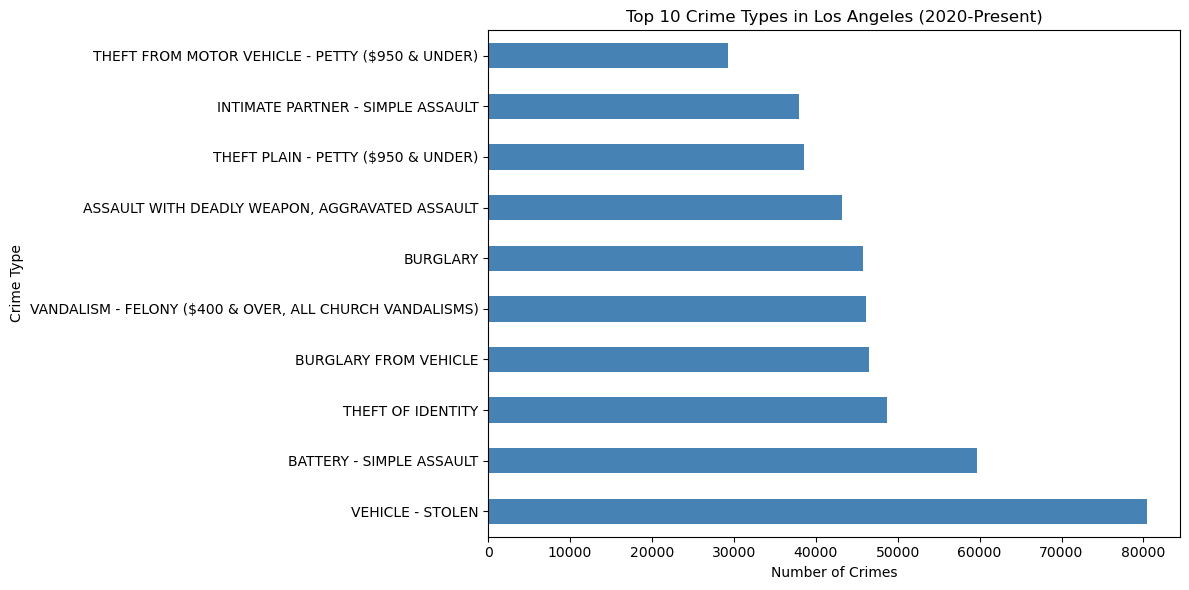

In [40]:
plt.figure(figsize=(12,6))
top_crimes.plot(kind='barh', color='steelblue')
plt.title('Top 10 Crime Types in Los Angeles (2020-Present)')
plt.xlabel('Number of Crimes')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()

In [41]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,...,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Month,Hour
0,10304468,2020-01-08,2020-01-08,2230,3,Southwest,BATTERY - SIMPLE ASSAULT,36.0,F,B,...,SINGLE FAMILY DWELLING,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,1100 W 39TH PL,34.0141,-118.2978,2020,1,22
1,190101086,2020-01-02,2020-01-01,330,1,Central,BATTERY - SIMPLE ASSAULT,25.0,M,H,...,SIDEWALK,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,700 S HILL ST,34.0459,-118.2545,2020,1,3
2,200110444,2020-04-14,2020-02-13,1200,1,Central,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,NaN,X,X,...,POLICE FACILITY,No Weapon,AA,Adult Arrest,200 E 6TH ST,34.0448,-118.2474,2020,2,12
3,191501505,2020-01-01,2020-01-01,1730,15,N Hollywood,VANDALISM - MISDEAMEANOR ($399 OR UNDER),76.0,F,W,...,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",No Weapon,IC,Invest Cont,5400 CORTEEN PL,34.1685,-118.4019,2020,1,17
4,191921269,2020-01-01,2020-01-01,415,19,Mission,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",31.0,X,X,...,BEAUTY SUPPLY STORE,No Weapon,IC,Invest Cont,14400 TITUS ST,34.2198,-118.4468,2020,1,4


In [43]:
top_areas= df['AREA NAME'].value_counts().head(10)
top_areas

AREA NAME
Central        50499
77th Street    47682
Pacific        43879
Southwest      42061
Hollywood      40183
Southeast      38576
Olympic        38197
N Hollywood    37474
Newton         37429
Wilshire       35549
Name: count, dtype: int64

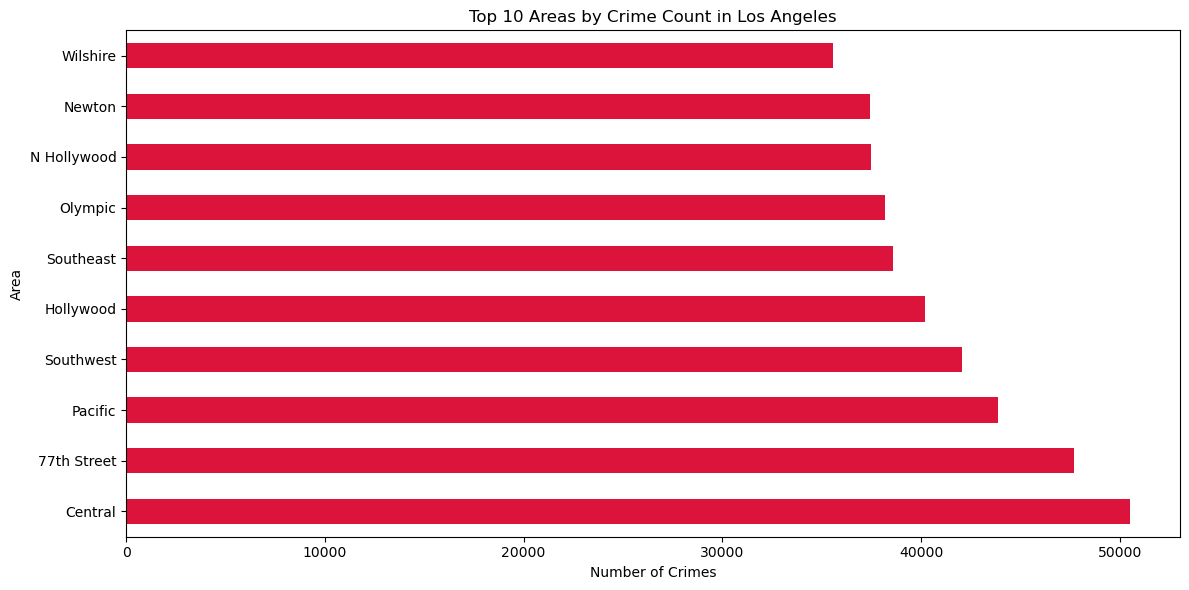

In [44]:
plt.figure(figsize=(12,6))
top_areas.plot(kind='barh', color='crimson')
plt.title('Top 10 Areas by Crime Count in Los Angeles')
plt.xlabel('Number of Crimes')
plt.ylabel('Area')
plt.tight_layout()
plt.show()

In [45]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,...,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Month,Hour
0,10304468,2020-01-08,2020-01-08,2230,3,Southwest,BATTERY - SIMPLE ASSAULT,36.0,F,B,...,SINGLE FAMILY DWELLING,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,1100 W 39TH PL,34.0141,-118.2978,2020,1,22
1,190101086,2020-01-02,2020-01-01,330,1,Central,BATTERY - SIMPLE ASSAULT,25.0,M,H,...,SIDEWALK,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,700 S HILL ST,34.0459,-118.2545,2020,1,3
2,200110444,2020-04-14,2020-02-13,1200,1,Central,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,NaN,X,X,...,POLICE FACILITY,No Weapon,AA,Adult Arrest,200 E 6TH ST,34.0448,-118.2474,2020,2,12
3,191501505,2020-01-01,2020-01-01,1730,15,N Hollywood,VANDALISM - MISDEAMEANOR ($399 OR UNDER),76.0,F,W,...,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",No Weapon,IC,Invest Cont,5400 CORTEEN PL,34.1685,-118.4019,2020,1,17
4,191921269,2020-01-01,2020-01-01,415,19,Mission,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",31.0,X,X,...,BEAUTY SUPPLY STORE,No Weapon,IC,Invest Cont,14400 TITUS ST,34.2198,-118.4468,2020,1,4


In [46]:
crimes_by_hour= df['Hour'].value_counts().sort_index()
crimes_by_hour

Hour
0     31232
1     22794
2     19305
3     16825
4     14187
5     13238
6     17373
7     19577
8     27840
9     27181
10    32121
11    32727
12    51385
13    33925
14    36526
15    39236
16    39521
17    43736
18    44724
19    41262
20    41823
21    38067
22    36840
23    31457
Name: count, dtype: int64

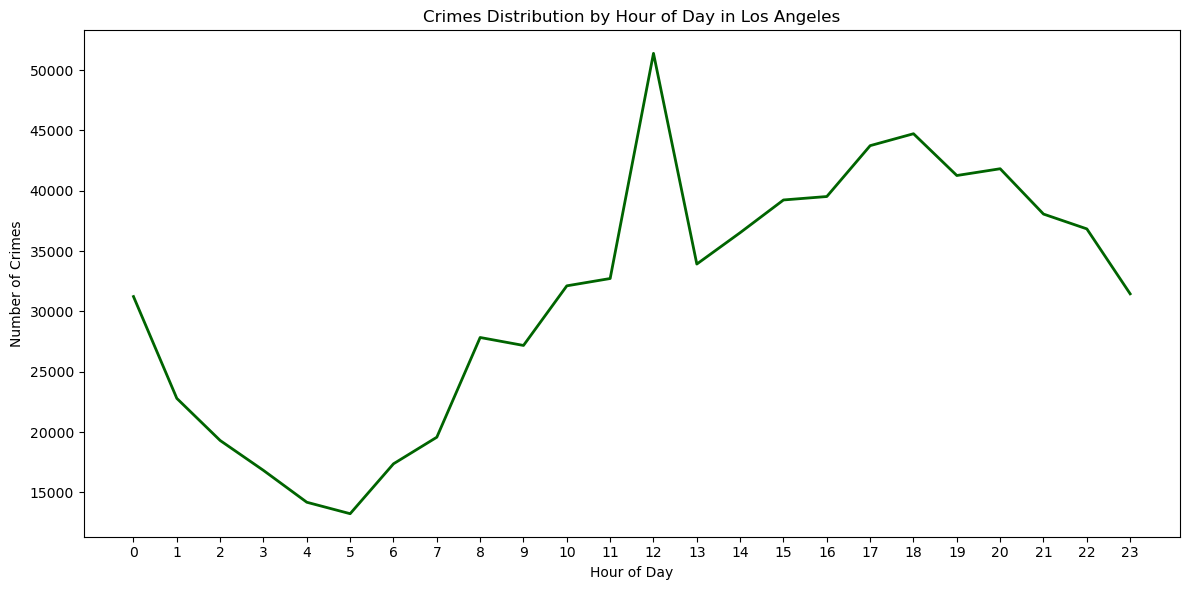

In [49]:
plt.figure(figsize=(12,6))
crimes_by_hour.plot(kind='line', color='darkgreen', linewidth=2)
plt.title('Crimes Distribution by Hour of Day in Los Angeles')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crimes')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

In [52]:
df['Vict Age'].dtype

dtype('float64')

In [51]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,...,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Month,Hour
0,10304468,2020-01-08,2020-01-08,2230,3,Southwest,BATTERY - SIMPLE ASSAULT,36.0,F,B,...,SINGLE FAMILY DWELLING,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,1100 W 39TH PL,34.0141,-118.2978,2020,1,22
1,190101086,2020-01-02,2020-01-01,330,1,Central,BATTERY - SIMPLE ASSAULT,25.0,M,H,...,SIDEWALK,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,700 S HILL ST,34.0459,-118.2545,2020,1,3
2,200110444,2020-04-14,2020-02-13,1200,1,Central,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,NaN,X,X,...,POLICE FACILITY,No Weapon,AA,Adult Arrest,200 E 6TH ST,34.0448,-118.2474,2020,2,12
3,191501505,2020-01-01,2020-01-01,1730,15,N Hollywood,VANDALISM - MISDEAMEANOR ($399 OR UNDER),76.0,F,W,...,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",No Weapon,IC,Invest Cont,5400 CORTEEN PL,34.1685,-118.4019,2020,1,17
4,191921269,2020-01-01,2020-01-01,415,19,Mission,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",31.0,X,X,...,BEAUTY SUPPLY STORE,No Weapon,IC,Invest Cont,14400 TITUS ST,34.2198,-118.4468,2020,1,4


In [53]:
df['LAT'].dtype

dtype('float64')

In [54]:
df[['Vict Age', 'LAT']].head(20)

,Vict Age,LAT
0,36.0,34.0141
1,25.0,34.0459
2,NaN,34.0448
3,76.0,34.1685
4,31.0,34.2198
5,25.0,34.0452
6,23.0,34.0483
7,NaN,34.0448
8,23.0,34.0677
9,NaN,34.2864


In [56]:
df['Vict Age']=df['Vict Age'].fillna(0)

In [57]:
df['Vict Age'].isnull().sum()

np.int64(0)

In [58]:
df['Vict Age'].dtype

dtype('float64')

In [59]:
path = r'C:\Users\MKcomputer\Documents\\'
df.to_csv(path + 'la_crimes_clean.csv', index=False)
print("✅ اتحفظ!")

✅ اتحفظ!


In [60]:
print(df['Vict Age'].isnull().sum())
print(df.shape)

0
(752902, 21)


In [61]:
df.to_csv('LA_Crimes_clean2.csv', index= False)

In [62]:
df['LAT'].isnull().sum()

np.int64(0)

In [64]:
df[df['LAT']==0].shape

(2266, 21)

In [65]:
df['LAT'].unique()[:20]

array([34.0141, 34.0459, 34.0448, 34.1685, 34.2198, 34.0452, 34.0483,
       34.0677, 34.2864, 34.0359, 34.0615, 34.048 , 34.0515, 34.3055,
       34.1186, 33.7926, 34.1857, 34.0463, 34.2039, 34.1748])

In [66]:
df.columns.tolist()

['DR_NO',
 'Date Rptd',
 'DATE OCC',
 'TIME OCC',
 'AREA',
 'AREA NAME',
 'Crm Cd Desc',
 'Vict Age',
 'Vict Sex',
 'Vict Descent',
 'Premis Cd',
 'Premis Desc',
 'Weapon Desc',
 'Status',
 'Status Desc',
 'LOCATION',
 'LAT',
 'LON',
 'Year',
 'Month',
 'Hour']

In [67]:
df.columns= ['DR_NO', 'Date_Rptd', 'Date_OCC', 'Time_OCC', 'Area_ID', 
              'Area_Name', 'Crm_Cd_Desc', 'Vict_Age', 'Vict_Sex', 
              'Vict_Descent', 'Premis_Cd', 'Premis_Desc', 'Weapon_Desc', 
              'Status', 'Status_Desc', 'Location', 'LAT', 'LON', 
              'Year', 'Month', 'Hour']

In [69]:
df.to_csv(r'C:\Users\MKcomputer\Documents\LA_Crime_Analysis\LA_Crimes_clean2.csv', index=False)

In [70]:
df.columns.tolist()

['DR_NO',
 'Date_Rptd',
 'Date_OCC',
 'Time_OCC',
 'Area_ID',
 'Area_Name',
 'Crm_Cd_Desc',
 'Vict_Age',
 'Vict_Sex',
 'Vict_Descent',
 'Premis_Cd',
 'Premis_Desc',
 'Weapon_Desc',
 'Status',
 'Status_Desc',
 'Location',
 'LAT',
 'LON',
 'Year',
 'Month',
 'Hour']

In [76]:
print(open(r'C:\Users\MKcomputer\Documents\la_crimes_clean.csv').readline())

DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,LAT,LON,Year,Month,Hour



In [75]:
print(open(r'C:\Users\MKcomputer\Documents\la_crimes_clean.csv').readlines()[1])

10304468,2020-01-08,2020-01-08,2230,3,Southwest,BATTERY - SIMPLE ASSAULT,36.0,F,B,501.0,SINGLE FAMILY DWELLING,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,1100 W  39TH                         PL,34.0141,-118.2978,2020,1,22



In [73]:
print(open(r'C:\Users\MKcomputer\Documents\la_crimes_clean.csv').readlines()[2])

190101086,2020-01-02,2020-01-01,330,1,Central,BATTERY - SIMPLE ASSAULT,25.0,M,H,102.0,SIDEWALK,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,700 S  HILL                         ST,34.0459,-118.2545,2020,1,3



In [74]:
df.to_csv(r'C:\Users\MKcomputer\Documents\LA_Crime_Analysis\LA_Crimes_clean2.csv', index=False, sep='|')

In [78]:
print(open(r'C:\Users\MKcomputer\Documents\LA_Crime_Analysis\LA_Crimes_clean2.csv').readline())

DR_NO|Date_Rptd|Date_OCC|Time_OCC|Area_ID|Area_Name|Crm_Cd_Desc|Vict_Age|Vict_Sex|Vict_Descent|Premis_Cd|Premis_Desc|Weapon_Desc|Status|Status_Desc|Location|LAT|LON|Year|Month|Hour

